In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from Analyze_Beagle_Output import *

In [21]:
Table.read('ghz2-container/OG_Jorge_Photom.fits')

ID,FLUX_F090W,FLUXERR_F090W,FLUX_F115W,FLUXERR_F115W,FLUX_F150W,FLUXERR_F150W,FLUX_F200W,FLUXERR_F200W,FLUX_F277W,FLUXERR_F277W,FLUX_F356W,FLUXERR_F356W,FLUX_F444W,FLUXERR_F444W,redshift
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1395,2.0063742159812,1.7273723303243,6.256960320962801,2.0261940220661,9.173521016382399,2.4225901437646002,67.1357816115011,2.3067205081912,54.3764002942159,1.183089963223,48.5829185155466,1.0397775192243,54.72096,0.8630359999999999,12.33


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_31804/25014522.py:1: SyntaxWarning: invalid escape sequence '\s'
  pd.read_csv('/Users/oac466/Downloads/GHZ2phot (1).cat', sep = '\s+').columns


Index(['#', 'ID', 'F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W',
       'F444W', 'err_F090W', 'err_F115W', 'err_F150W', 'err_F200W',
       'err_F277W', 'err_F356W', 'err_F444W'],
      dtype='object')

In [28]:
cols = ['ID', 'F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W',
           'F444W', 'err_F090W', 'err_F115W', 'err_F150W', 'err_F200W',
           'err_F277W', 'err_F356W', 'err_F444W']

In [30]:
pd.read_csv('/Users/oac466/Downloads/GHZ2phot (1).cat', sep = '\s+', names=cols, skiprows=1)*1000

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_31804/1183312508.py:1: SyntaxWarning: invalid escape sequence '\s'
  pd.read_csv('/Users/oac466/Downloads/GHZ2phot (1).cat', sep = '\s+', names=cols, skiprows=1)*1000


,ID,F090W,F115W,F150W,F200W,F277W,F356W,F444W,err_F090W,err_F115W,err_F150W,err_F200W,err_F277W,err_F356W,err_F444W
0,29501000,2.006374,6.25696,9.173521,67.135782,54.3764,48.582919,54.72096,1.727372,2.026194,2.42259,2.306721,1.18309,1.039778,0.863036


In [3]:
wave,flux, fluxerr =  read_nirspec_data()

# Reading in the Data

In [4]:
hdu_agn_mup100_default  = fits.open('Final_Runs/AGN_Mup100_default_anshbranch_13_fixed_pl.fits.gz')
hdu_agn_mup100_CO       = fits.open('Final_Runs/AGN_Mup100_Nebular_CO_Grids_anshbranch_13_fixed_pl.fits.gz')
hdu_agn_mup100_co_logu  = fits.open('Final_Runs/AGN_Mup100_Nebular_CO_Grids_w_logU_anshbranch_13_fixed_pl.fits.gz')
hdu_agn_mup100_logU     = fits.open('Final_Runs/AGN_Mup100_logU_anshbranch_13_fixed_pl.fits.gz')

hdu_agn_mup300_default  = fits.open('Final_Runs/AGN_Mup300_default_anshbranch_13_fixed_pl.fits.gz')
hdu_agn_mup300_CO       = fits.open('Final_Runs/AGN_Mup300_Nebular_CO_Grids_anshbranch_13_fixed_pl.fits.gz')
hdu_agn_mup300_co_logu  = fits.open('Final_Runs/AGN_Mup300_Nebular_CO_Grids_w_logU_anshbranch_13_fixed_pl.fits.gz')
hdu_agn_mup300_logU     = fits.open('Final_Runs/AGN_Mup300_logU_anshbranch_13_fixed_pl.fits.gz')

hdu_sf_mup100           = fits.open('Final_Runs/SF_Mup100_Default_anshbranch_13_fixed_pl.fits.gz')
hdu_sf_mup100_co        = fits.open('Final_Runs/SF_Mup100_Nebular_CO_anshbranch_13_fixed_pl.fits.gz')
hdu_sf_mup300           = fits.open('Final_Runs/SF_Mup300_Default_anshbranch_13_fixed_pl.fits.gz')
hdu_sf_mup300_co        = fits.open('Final_Runs/SF_Mup300_Nebular_CO_anshbranch_13_fixed_pl.fits.gz') 

In [8]:
check = pd.read_csv('data/spectra/OG_MIRI_Spectra_Feb28.txt', sep = ' ', names=['wave', 'flux', 'flux_err'])

In [17]:
miri = Table.read('data/spectra/OG_MIRI_Spectra_Feb28.txt', format='ascii')

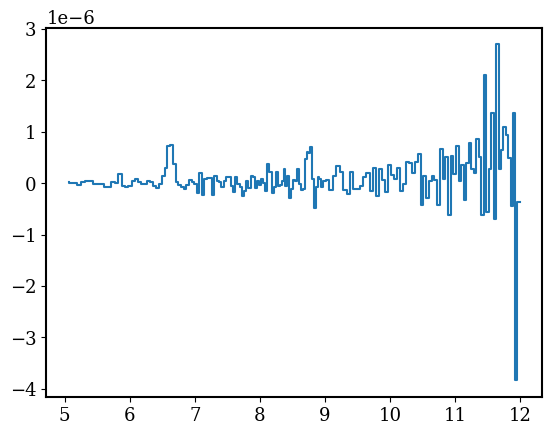

In [18]:
plt.step(miri['col1'], miri['col2'])

# Diagnostic Plots

In [5]:
def plot_marginal_panels(hdul, wave, flux, fluxerr, kind):
    fsize = 20
    mult = 1e20
    if kind == 'agn':
        labels = ['AGN Mup100', 'AGN Mup300', 'SF Mup100', 'SF Mup300']
        colors = ['blue', 'red', 'orange', 'salmon']
    
        nrows = 4
        ncols = 1
    else:
        labels = ['mup100', 'mup300']
        colors = ['blue', 'red']
    
        nrows = 2
        ncols = 1
    
    fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (15, 5), facecolor = 'white', dpi = 150)
    ax.step(wave/1e4, flux*mult, color = 'gray')
    for hdu, l, c in zip(hdul, labels, colors):
        #bic = grab_bic(hdu, wave, flux, fluxerr)
        marg_wave, marg_seds = grab_marginal(hdu)
        #print(marg_wave)
        l16, med, u84 = np.percentile(marg_seds, q = (16, 50, 84), axis = 0)
        ax.step(marg_wave/1e4, med*mult, label = f'{l}', color = c)
        ax.fill_between(marg_wave/1e4, u84*mult, l16*mult, color = c, alpha = 0.5, step = 'mid')
        
    ax.set_xlim(1.5,5.5)
    ax.set_ylim(-0.5, 1.2)
    ax.legend()
    ax.set_xlabel(r'Wavelength [$\mu$m]', fontsize = 15)
    ax.set_ylabel(r'F$_{\lambda}$ [1$\times 10^{-20}$ erg/s/$cm^2$/Hz]', fontsize = 15)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.tick_params(axis='both', which='major', direction='in')
    #plt.show()
    
    return fig, ax

In [ ]:
[hdu_agn_mup300_default, hdu_agn_mup300_all_co, hdu_agn_mup300_logU], 
[hdu_agn_mup100_default, hdu_agn_mup100_all_co, hdu_agn_mup100_logU_free_pl]#hdu_agn_mup100_logU]
                     [hdu_sf_mup100, hdu_sf_mup300],

In [ ]:
[hdu_agn_mup100_default, hdu_agn_mup300_default, hdu_sf_mup100, hdu_sf_mup300]

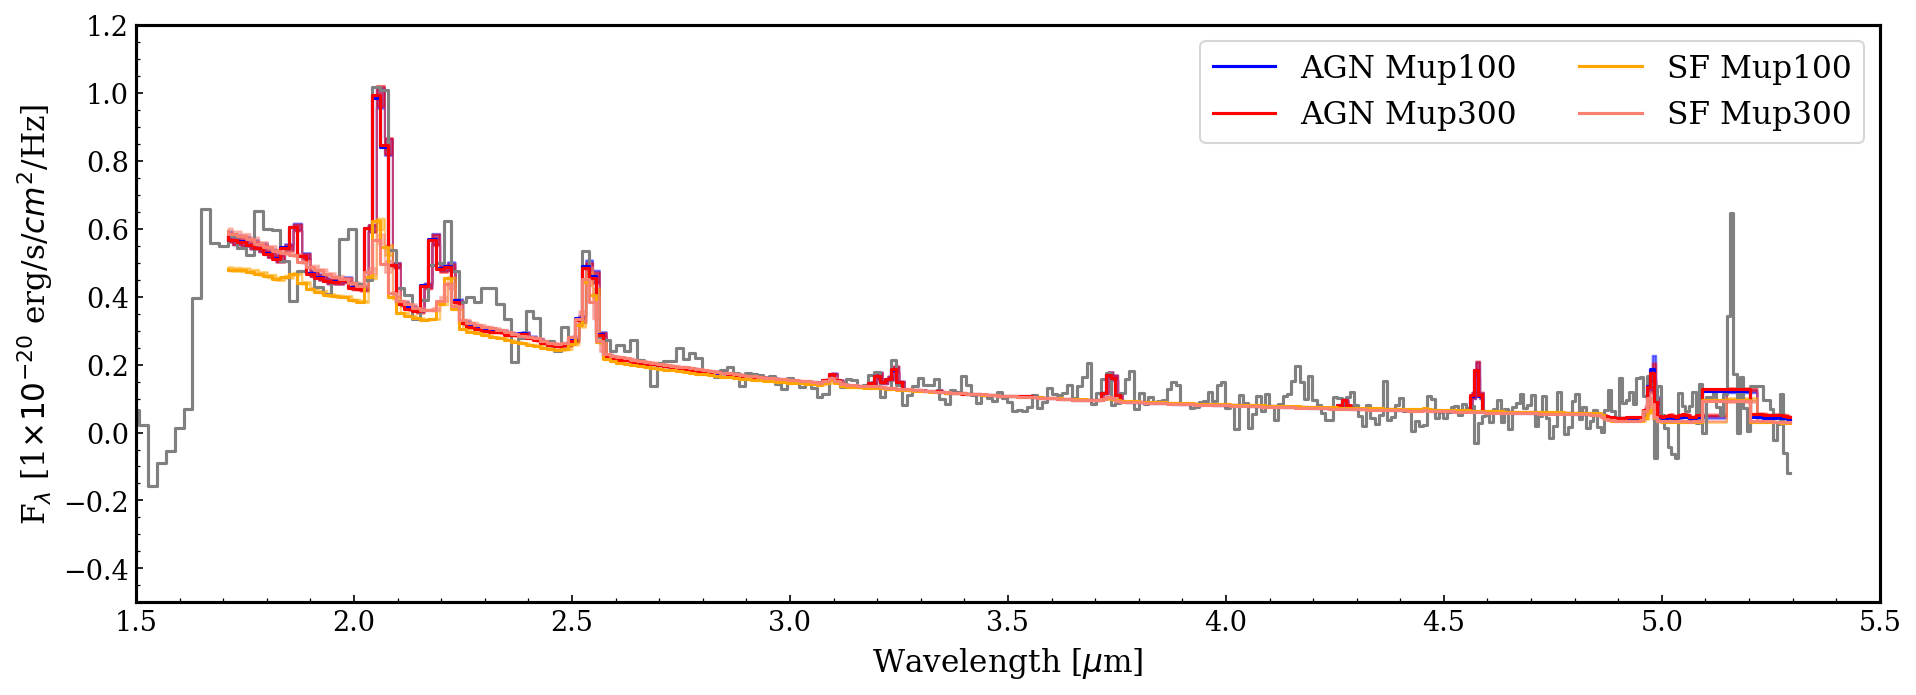

In [80]:
fig, ax = plot_marginal_panels([hdu_agn_mup100_default, hdu_agn_mup300_default, hdu_sf_mup100, hdu_sf_mup300], 
                                  wave, flux, fluxerr, 'agn')
ax.legend(ncols = 2, fontsize = 15)
plt.show()

# Corner Plots

In [9]:
import seaborn as sb

In [65]:
corner_plot_cols = ['metallicity', 
                    'mass', 
                    'specific_sfr',
                    'nebular_logu', 
                    'nebular_z',  
                    'agn_lacc',
                    'agn_logu', 
                    'agn_xi', 
                    'agn_z']

# Fractional contribution in HII region and AGN Emission 
# Fractional contirbution in the Oxygen 
# Need to look over the param file on TACC for these
# Fix Xid in the fiducial runs to compare to the C/O
# C/O for the stellar only one but need to get grids
# look into the current sfr timescale and this controls the time scale of younger stars

In [18]:
df_mup100_default = get_posterior_df(hdu_agn_mup100_default)
df_mup100_CO = get_posterior_df(hdu_agn_mup100_CO)
df_mup100_co_logu = get_posterior_df(hdu_agn_mup100_co_logu)
df_mup100_logu = get_posterior_df(hdu_agn_mup100_logU)

In [19]:
df_mup300_default = get_posterior_df(hdu_agn_mup300_default)
df_mup300_logu = get_posterior_df(hdu_agn_mup300_logU)
df_mup300_CO_logu = get_posterior_df(hdu_agn_mup300_co_logu)
df_mup300_CO = get_posterior_df(hdu_agn_mup300_CO)

In [20]:
df_mup100_logu['agn_logu'] = df_mup100_logu.agn_logu.values+1
df_mup100_co_logu['agn_logu'] = df_mup100_co_logu.agn_logu.values+1
df_mup300_logu['agn_logu'] = df_mup300_logu.agn_logu.values+1
df_mup300_CO_logu['agn_logu'] = df_mup300_CO_logu.agn_logu.values+1

In [21]:
stellar_plus_agn = ['nebular_logu', 'nebular_z', 'agn_lacc', 'agn_logu', 'agn_xi', 'agn_z']

In [ ]:
xi_d = [0.1 , 0.5]
co = [0.1 , 1.4]
(i - co_min) * (xid_max - xid_min) / (co_max - co_min) + xid_min

In [105]:
def xid_to_co(xid_value, co_range=(0.1, 1.4), xid_range=(0.1, 0.5)):
    co_min, co_max = co_range
    xid_min, xid_max = xid_range
    co = (xid_value - xid_min) * (co_max - co_min) / (xid_max - xid_min) + co_min
    return co

In [22]:
#df_mup100_CO['C/O'] = xid_to_co(df_mup100_CO.agn_xi.values)

In [23]:
#df_mup100_CO['C/O'].hist(bins = 30)

In [24]:
from scipy.stats import gaussian_kde

In [25]:
confidence_levels = [0.68, 0.95, 0.997]

In [26]:
def kde_contour_percentiles(x, y, color='black', **kwargs):
    if len(x) < 10:
        return  # not enough points to make a KDE

    # 2D KDE
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    
    # Grid
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    xx, yy = np.meshgrid(x_grid, y_grid)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # Compute contour levels for desired percentiles
    zz_flat = zz.flatten()
    zz_sorted = np.sort(zz_flat)[::-1]
    cdf = np.cumsum(zz_sorted)
    cdf /= cdf[-1]

    levels = sorted(set([zz_sorted[np.searchsorted(cdf, cl)] for cl in confidence_levels]))

    plt.contour(xx, yy, zz, levels=levels, colors=color, linewidths=1, **kwargs)

In [136]:
df_mup100_default.columns

Index(['probability', 'ln_likelihood', 'chi_square', 'n_data', 'tau',
       'metallicity', 'mass', 'max_stellar_age', 'specific_sfr',
       'current_sfr_timescale', 'frac_type1_1500', 'type1_attenuation_tau_v',
       'redshift', 'nebular_logu', 'nebular_z', 'tauv_eff', 'agn_lacc',
       'agn_logu', 'agn_xi', 'agn_z'],
      dtype='object')

In [141]:
#sb.pairplot(df_mup100_CO[['frac_type1_1500', 'type1_attenuation_tau_v']], corner = True)

In [119]:
with_co = stellar_plus_agn + ['C/O']

In [121]:
df_mup100_CO['C/O'] = xid_to_co(df_mup100_CO.agn_xi.values)

In [132]:
df_mup300_CO['C/O'] = xid_to_co(df_mup300_CO.agn_xi.values)

In [27]:
stellar_plus_agn = ['nebular_logu',
 'nebular_z',
 'agn_lacc',
 'agn_logu',
 'agn_xi',
 'agn_z',
 #'model'
                   ]

In [30]:
corner_mup100_default = df_mup100_default[stellar_plus_agn]
corner_mup100_logu = df_mup100_logu[stellar_plus_agn]

corner_mup100_default['model'] = 'SF+AGN Mup100'
corner_mup100_logu['model'] = 'SF+AGN Mup100 Extended logU'

df = pd.concat([corner_mup100_default, corner_mup100_logu], ignore_index=True)

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_3017/906196289.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corner_mup100_default['model'] = 'SF+AGN Mup100'
/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_3017/906196289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corner_mup100_logu['model'] = 'SF+AGN Mup100 Extended logU'


In [32]:
import seaborn as sb

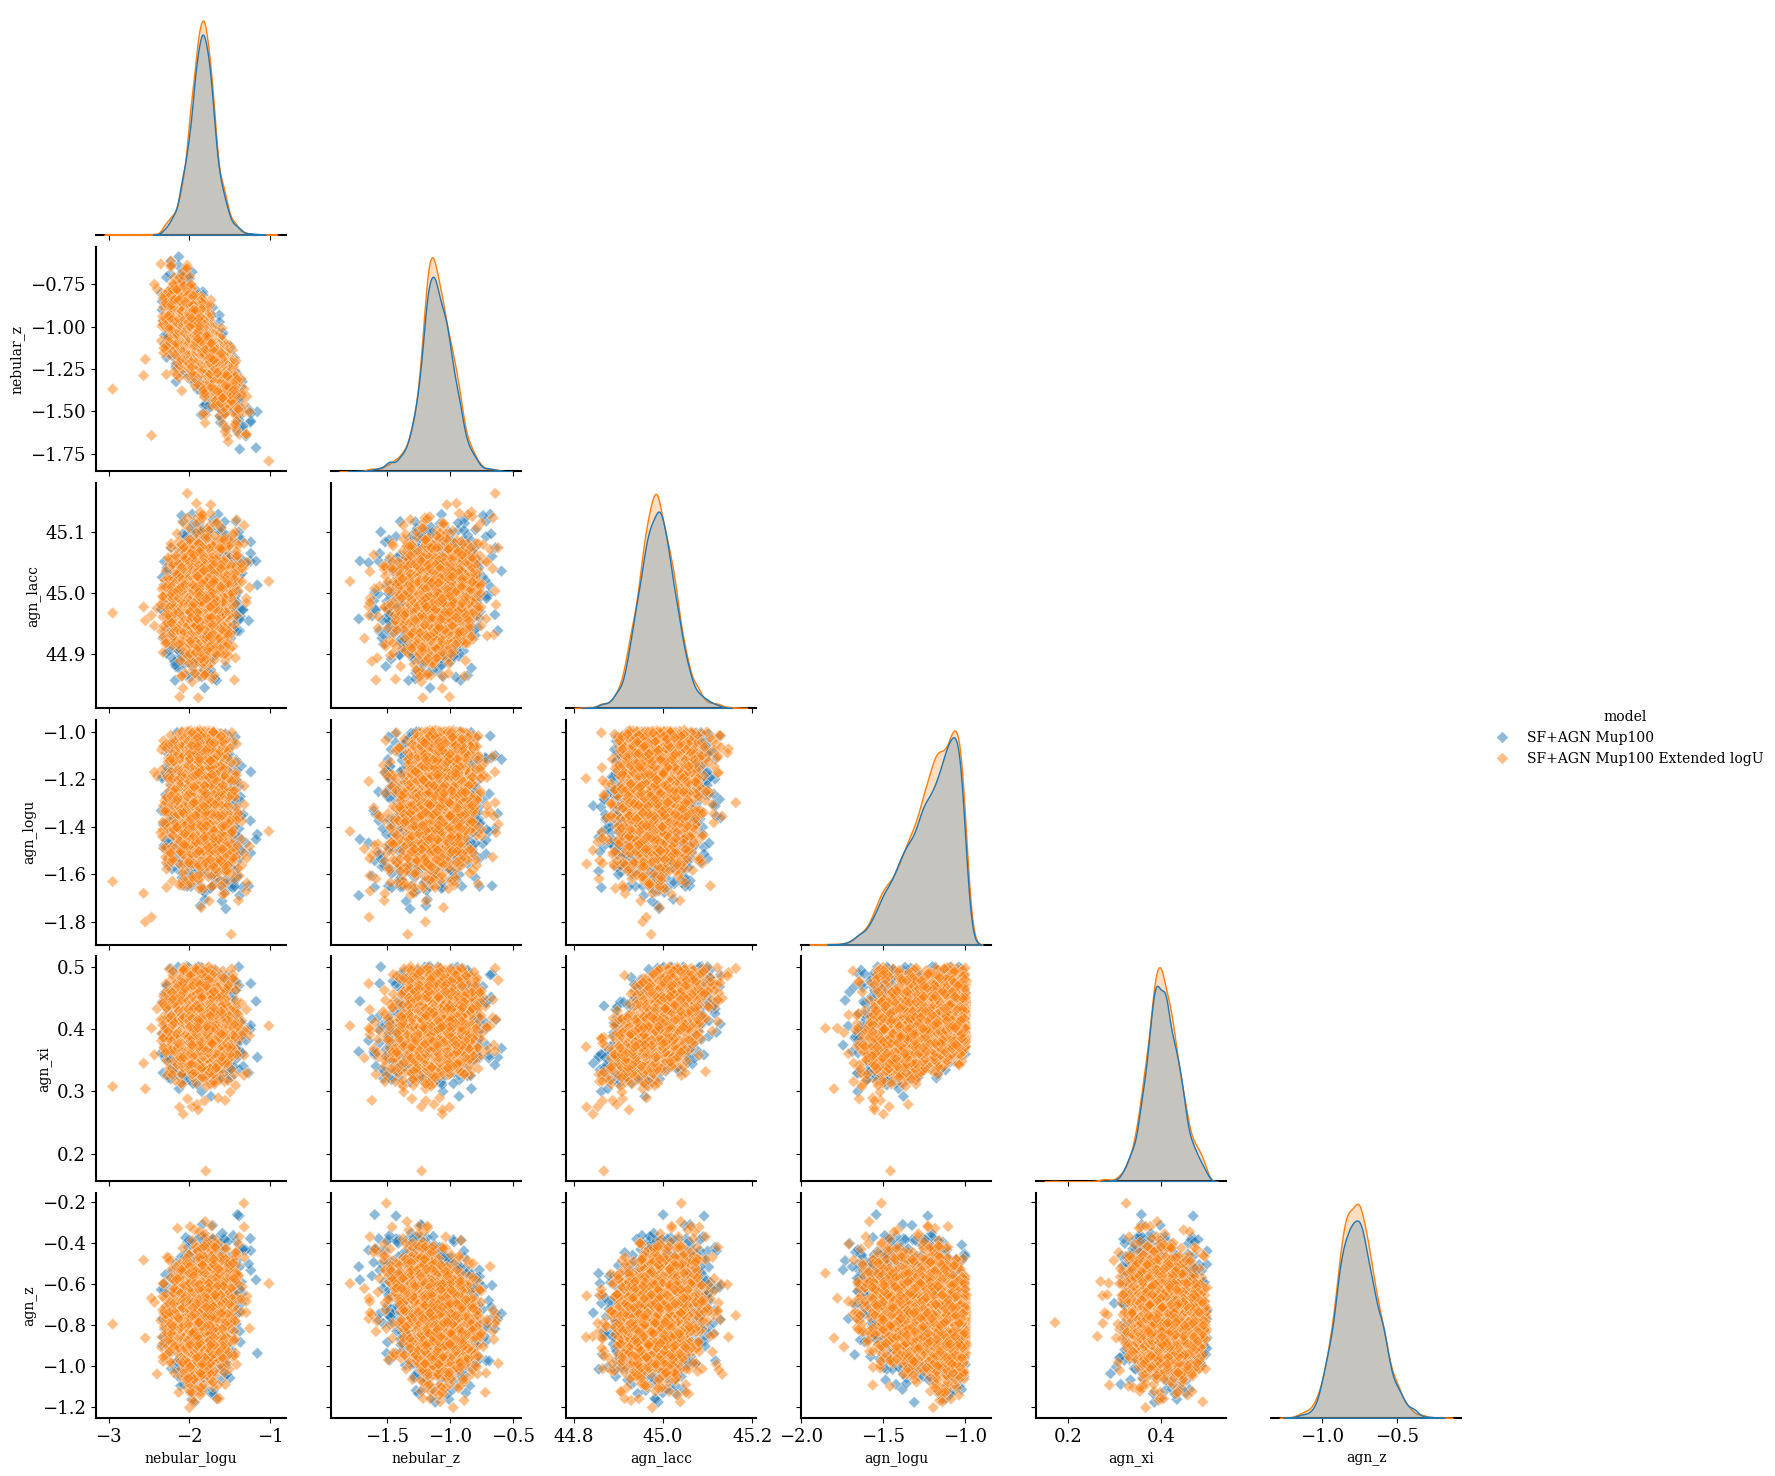

In [35]:
sb.pairplot(df, hue = 'model', corner = True, plot_kws = {'marker':'D', 'alpha' : 0.5}, dropna=True)

In [36]:
corner_mup100_default = df_mup100_default[stellar_plus_agn]
corner_mup300_default = df_mup300_default[stellar_plus_agn]

corner_mup100_default['model'] = 'SF+AGN Mup100'
corner_mup300_default['model'] = 'SF+AGN Mup300'

df = pd.concat([corner_mup100_default, corner_mup300_default], ignore_index=True)

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_3017/463172842.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corner_mup100_default['model'] = 'SF+AGN Mup100'
/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_3017/463172842.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corner_mup300_default['model'] = 'SF+AGN Mup300'


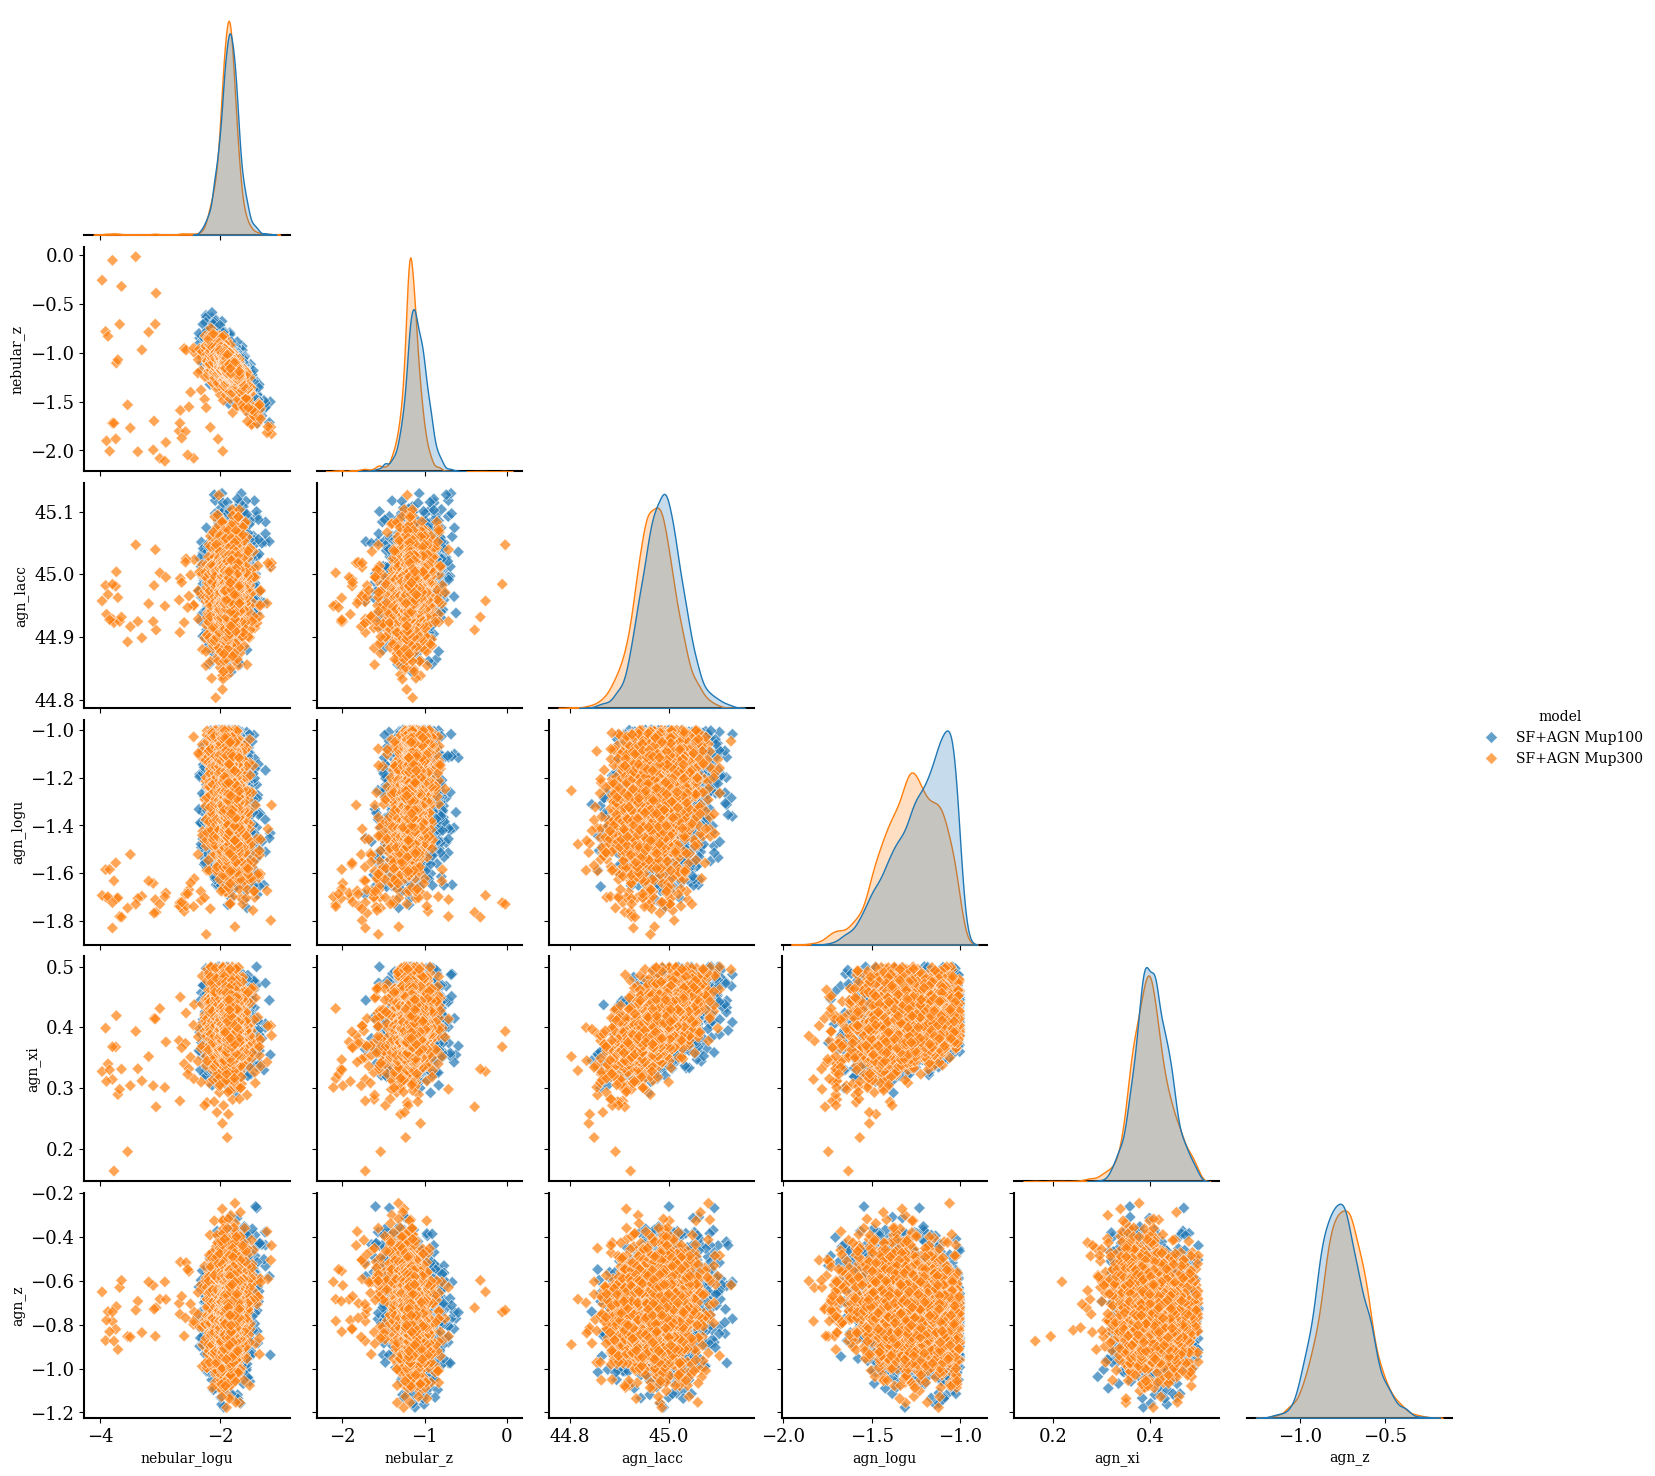

In [37]:
g = sb.pairplot(df, hue = 'model', corner = True, plot_kws = {'marker':'D', 'alpha' : 0.7}, dropna=True)
plt.show()

In [311]:
# df_mup100_CO['C/O'] = xid_to_co(df_mup100_CO['agn_xi'].values)
# df_mup300_CO['C/O'] = xid_to_co(df_mup300_CO['agn_xi'].values)

In [38]:
# corner_mup100_CO = df_mup100_CO[with_co]
# corner_mup300_CO = df_mup300_CO[with_co]

# corner_mup100_CO['model'] = 'SF+AGN Mup100 AGN C/O'
# corner_mup300_CO['model'] = 'SF+AGN Mup300 AGN C/O'

# df = pd.concat([corner_mup100_CO, corner_mup300_CO], ignore_index=True)

In [39]:
# corner_mup100_logu = df_mup100_logu[stellar_plus_agn]
# corner_mup300_logu = df_mup300_logu[stellar_plus_agn]

# corner_mup100_logu['model'] = 'SF+AGN Mup100 AGN C/O'
# corner_mup300_logu['model'] = 'SF+AGN Mup300 AGN C/O'

# df = pd.concat([corner_mup100_logu, corner_mup300_logu], ignore_index=True)

In [209]:
def make_comparison_corner(hdul, order = ['SF+AGN Mup100', 'SF+AGN Mup100 AGN CO', 'SF+AGN Mup100 Nebular CO + AGN logU', 'SF+AGN Mup100 AGN logU',
                                          'SF+AGN Mup300', 'SF+AGN Mup300 AGN CO', 'SF+AGN Mup300 Nebular CO + AGN logU', 'SF+AGN Mup300 AGN logU'
                                          'SF Mup100', 'SF Mup300', 'SF Mup100 + Nebular CO', 'SF Mup300 + Nebular CO']):

    stellar_plus_agn = ['nebular_logu', 'nebular_z', 'agn_lacc', 'agn_logu', 'agn_xi', 'agn_z', 'model']
    
    df_list = []
    
    for model, hdu in zip(order,hdul):
        df = get_posterior_df(hdu)
        
        if 'logU' in model:
            df['agn_logu'] = df.agn_logu.values+1
        if 'SF' in model:
            df['agn_lacc'] = np.nan
            df['agn_logu'] = np.nan
            df['agn_xi']   = np.nan
            df['agn_z']    = np.nan

        df['model'] = model
        df_list.append(df[stellar_plus_agn])

    

    merge_df = pd.concat(df_list, ignore_index=True)

    g = sb.pairplot(merge_df, hue = 'model', corner = True, plot_kws = {'marker':'D', 'alpha' : 0.7}, dropna=True)
    plt.show()
        

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_3017/468871589.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merge_df = pd.concat(df_list, ignore_index=True)


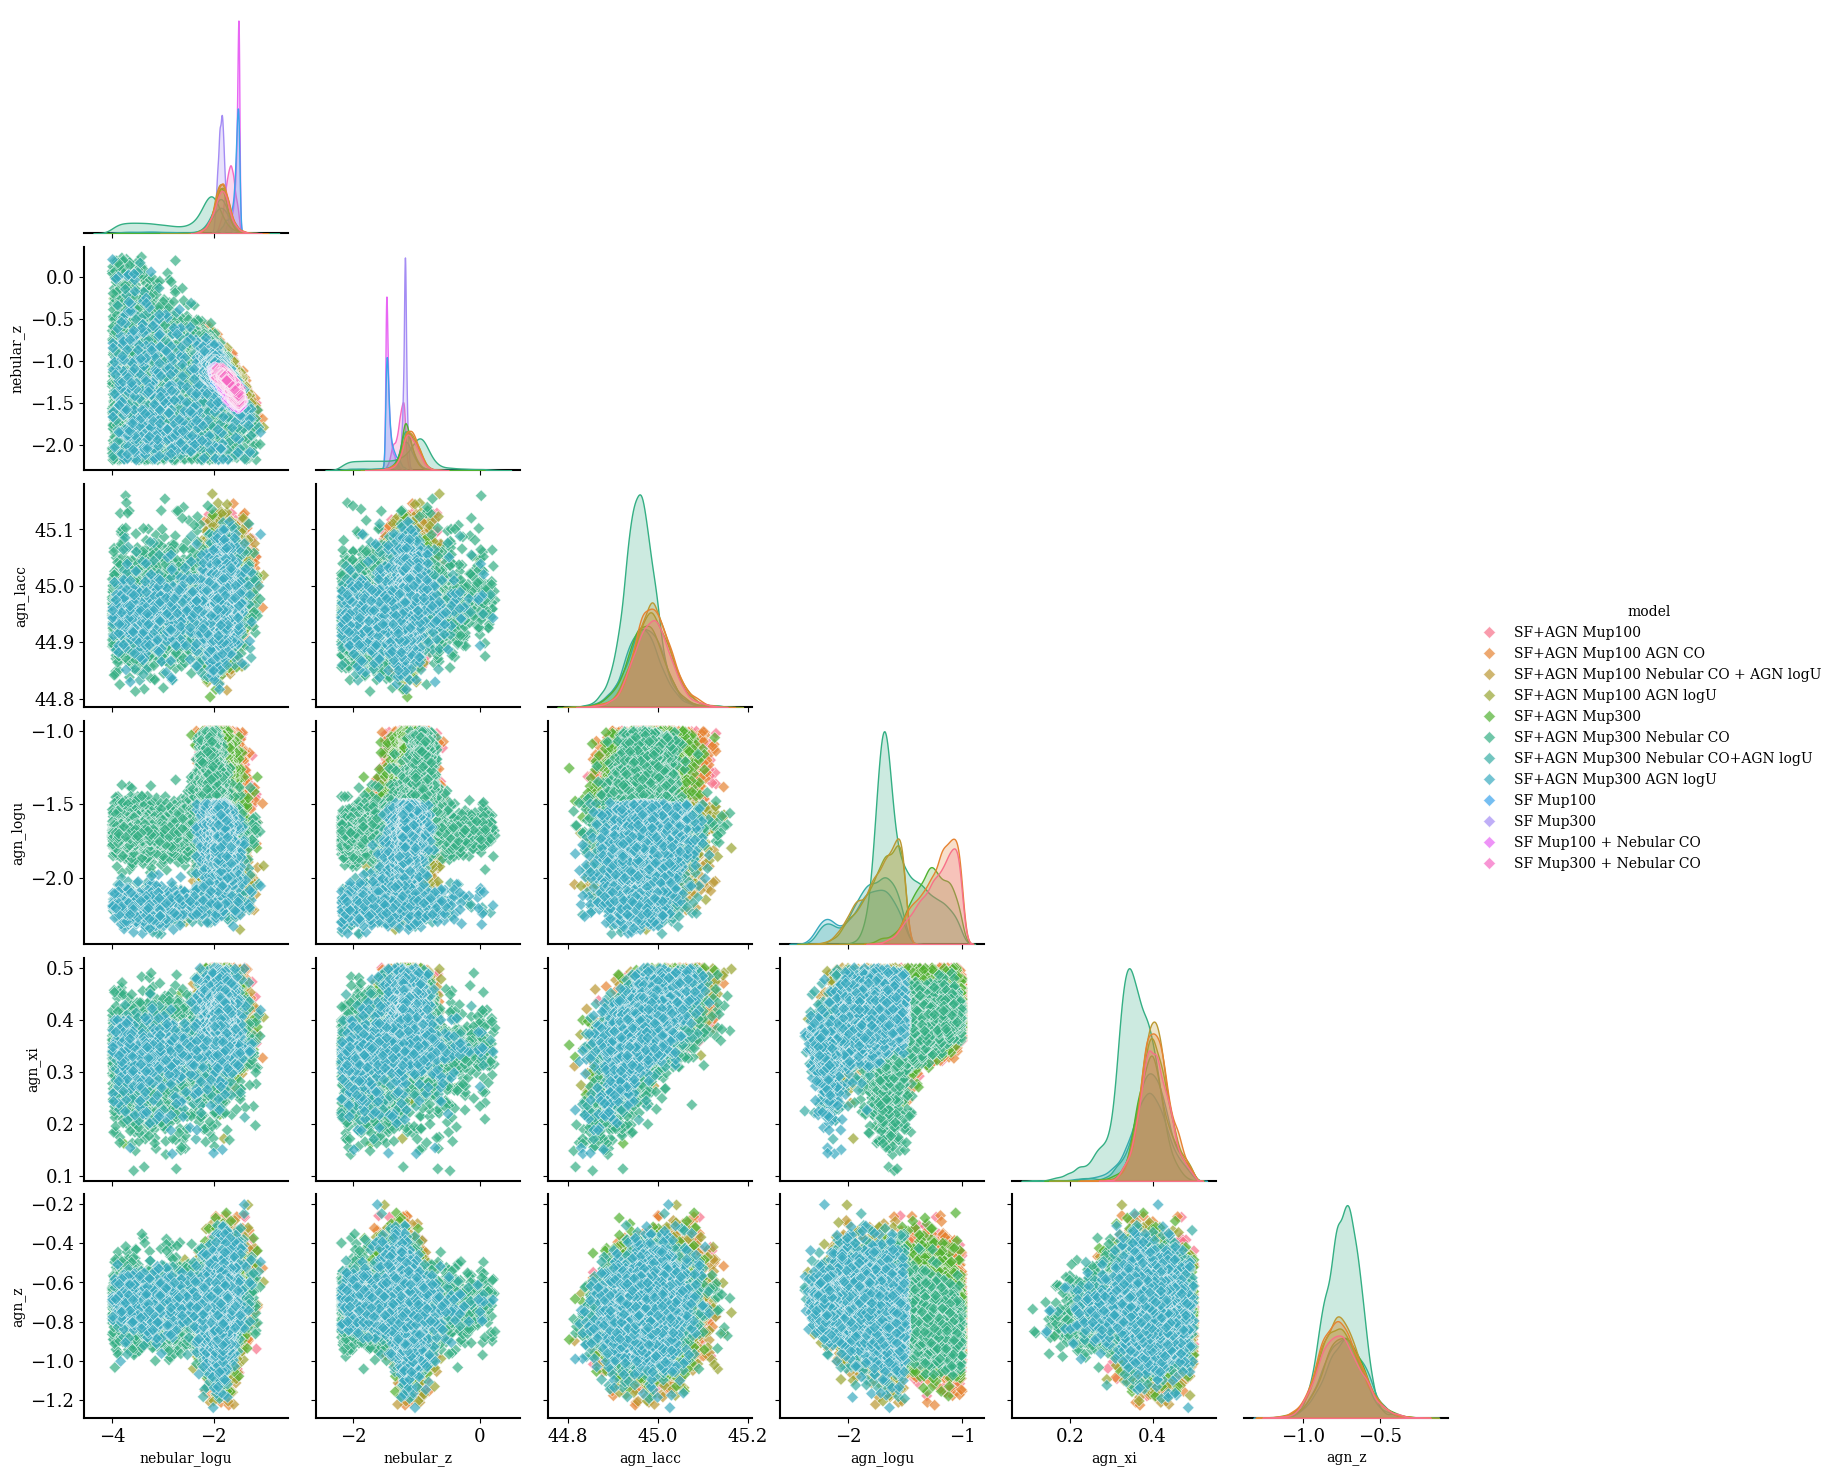

In [41]:
stellar_plus_agn = ['nebular_logu', 'nebular_z', 'agn_lacc', 'agn_logu', 'agn_xi', 'agn_z', 'model']
hdul = [hdu_agn_mup100_default, hdu_agn_mup100_CO, hdu_agn_mup100_co_logu,hdu_agn_mup100_logU, 
                        hdu_agn_mup300_default, hdu_agn_mup300_CO, hdu_agn_mup300_co_logu, hdu_agn_mup300_logU, 
                        hdu_sf_mup100, hdu_sf_mup300, hdu_sf_mup100_co, hdu_sf_mup300_co]
order = ['SF+AGN Mup100', 'SF+AGN Mup100 AGN CO', 'SF+AGN Mup100 Nebular CO + AGN logU', 'SF+AGN Mup100 AGN logU', 
          'SF+AGN Mup300', 'SF+AGN Mup300 Nebular CO', 'SF+AGN Mup300 Nebular CO+AGN logU', 'SF+AGN Mup300 AGN logU', 
          'SF Mup100', 'SF Mup300', 'SF Mup100 + Nebular CO', 'SF Mup300 + Nebular CO']
df_list = []

for model, hdu in zip(order,hdul):
    df = get_posterior_df(hdu)
    
    if 'logU' in model:
        df['agn_logu'] = df.agn_logu.values+0.5
    if 'AGN' not in model:
        df['agn_lacc'] = np.nan
        df['agn_logu'] = np.nan
        df['agn_xi']   = np.nan
        df['agn_z']    = np.nan

    df['model'] = model
    df_list.append(df[stellar_plus_agn])



merge_df = pd.concat(df_list, ignore_index=True)

g = sb.pairplot(merge_df, hue = 'model', corner = True, plot_kws = {'marker':'D', 'alpha' : 0.7}, dropna=True)
plt.show()

In [1]:
# plt.scatter([0.1123, 0.1307, 0.1523, 0.1861, 0.3769, 0.5], [0.14, 0.2, 0.27, 0.38, 1.0, 1.4])
# plt.plot([0.1123, 0.5], [0.14, 1.4])

In [42]:
rename_cols = {'nebular_logu': r'Nebular log$_{10}$(U)', 
               'nebular_z': r'Nebular log$_{10}$(Z/Z$_{\odot}$)', 
               'agn_lacc': r'log$_{10}$(L$_{acc}$)', 
               'agn_logu':  r'AGN log$_{10}$(U)', 
               'agn_xi': r'$\xi_{AGN}$',
               'agn_z': r'AGN log$_{10}$(Z/Z$_{\odot}$)'}

In [43]:
merge_df.rename(columns=rename_cols)

,Nebular log$_{10}$(U),Nebular log$_{10}$(Z/Z$_{\odot}$),log$_{10}$(L$_{acc}$),AGN log$_{10}$(U),$\xi_{AGN}$,AGN log$_{10}$(Z/Z$_{\odot}$),model
0,-1.891330,-1.250033,45.062332,-1.107479,0.389801,-0.773077,SF+AGN Mup100
1,-1.969989,-1.251441,44.947662,-1.470354,0.381508,-0.735184,SF+AGN Mup100
2,-2.010879,-1.223434,45.063774,-1.281095,0.419212,-0.686407,SF+AGN Mup100
3,-1.384836,-1.427255,45.092178,-1.229783,0.469645,-0.267635,SF+AGN Mup100
4,-1.244010,-1.564815,45.051891,-1.375239,0.399482,-0.377908,SF+AGN Mup100
...,...,...,...,...,...,...,...
34454,-1.741791,-1.223666,NaN,NaN,NaN,NaN,SF Mup300 + Nebular CO
34455,-1.743976,-1.220610,NaN,NaN,NaN,NaN,SF Mup300 + Nebular CO
34456,-1.691749,-1.262996,NaN,NaN,NaN,NaN,SF Mup300 + Nebular CO
34457,-1.749221,-1.234518,NaN,NaN,NaN,NaN,SF Mup300 + Nebular CO


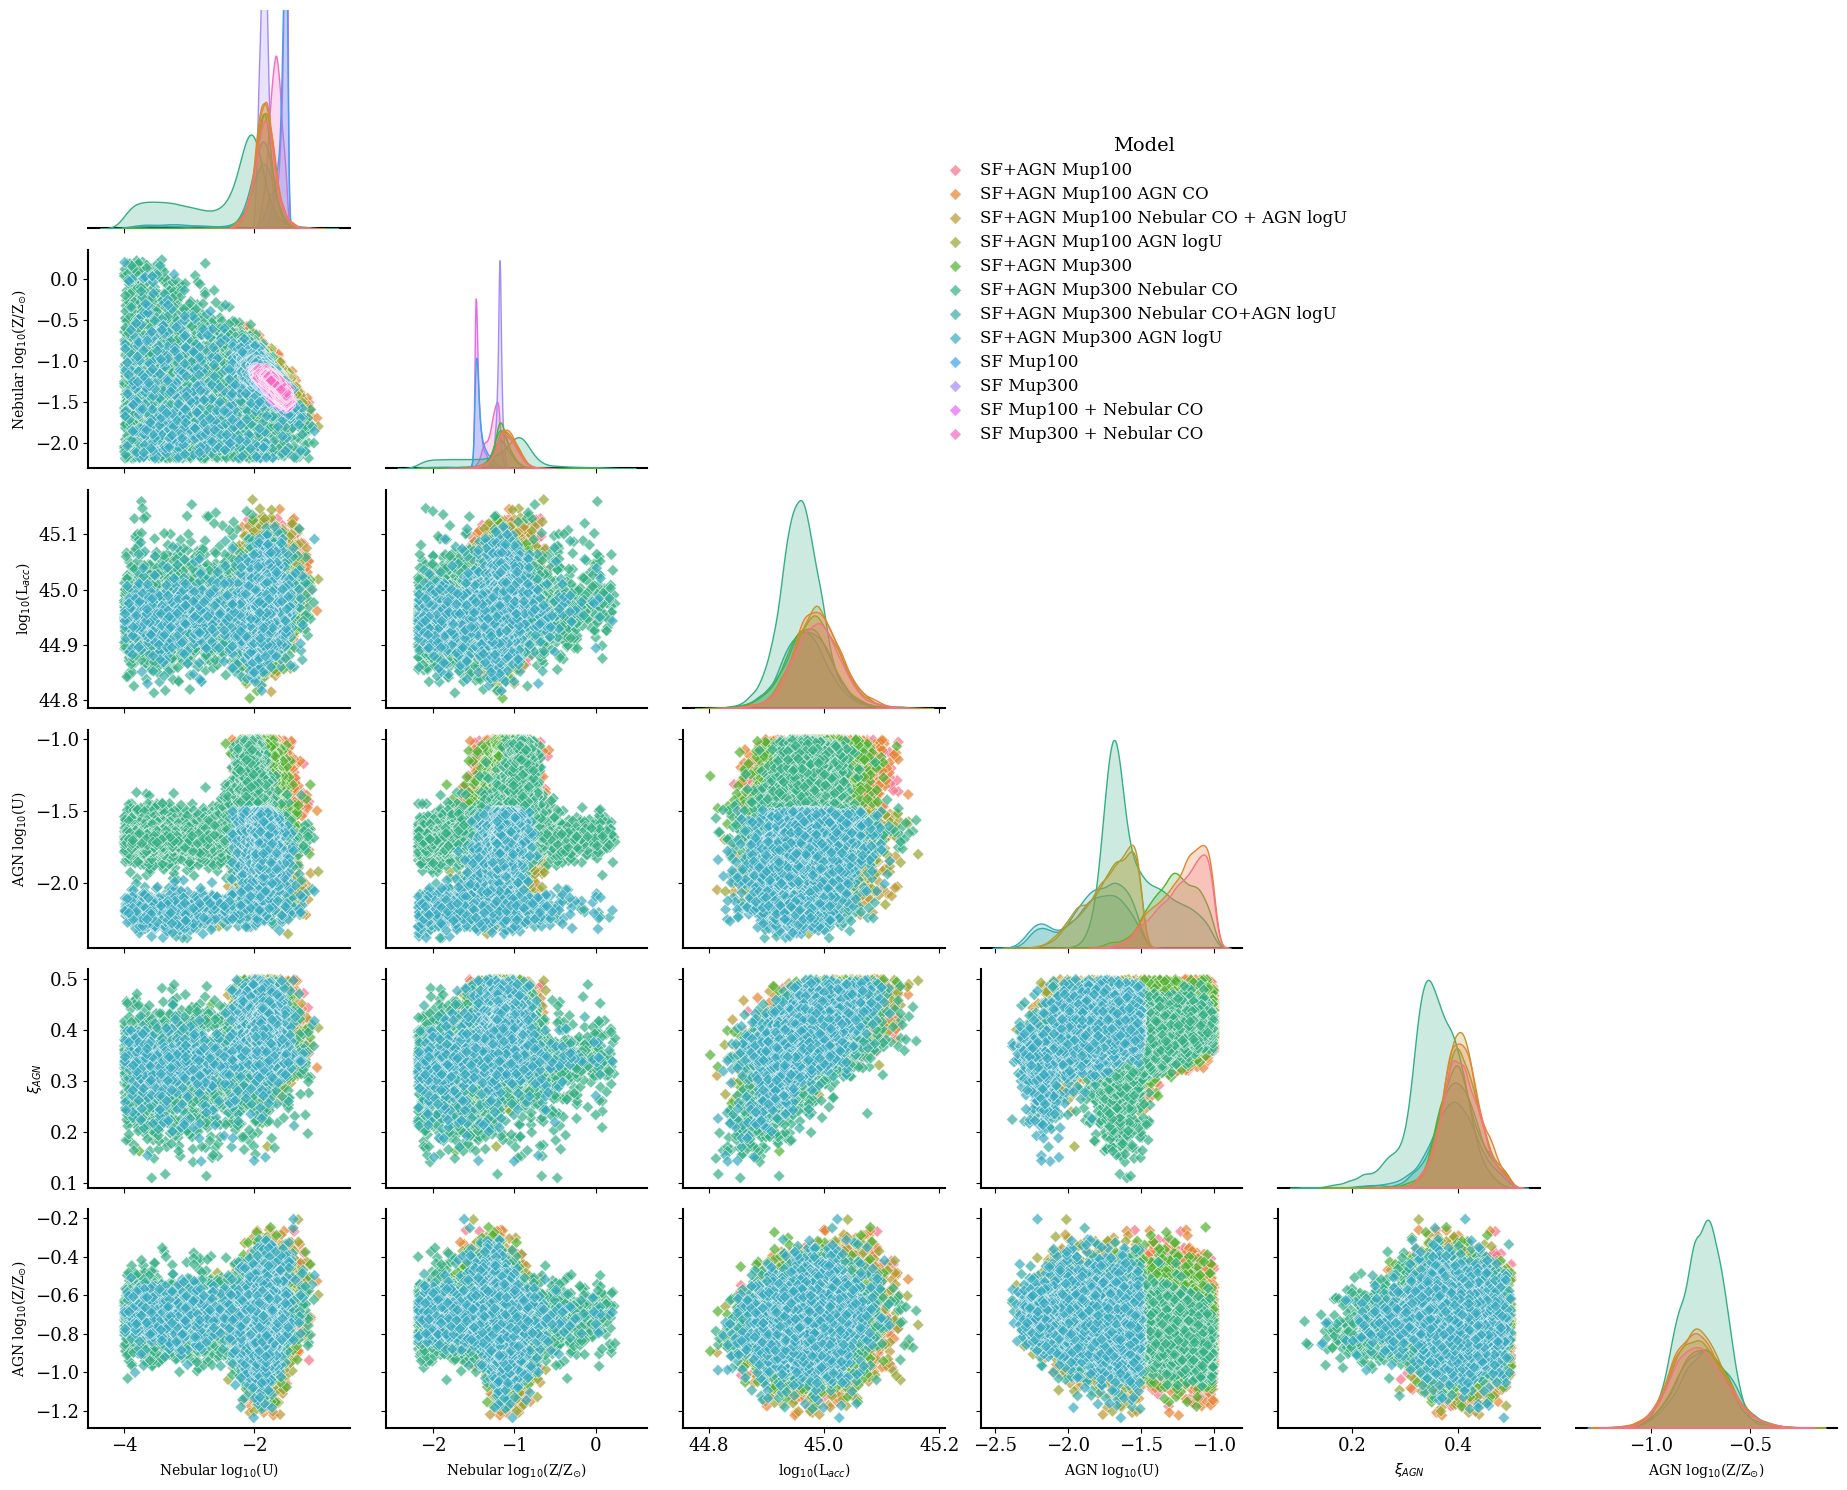

In [44]:
g = sb.pairplot(merge_df.rename(columns=rename_cols), hue = 'model', corner = True, plot_kws = {'marker':'D', 'alpha' : 0.7}, dropna=True)
ax = g.diag_axes[0]
ax.set_ylim(0, 0.4)
#for ax in g.diag_axes:
 # Cap height at a fixed value (e.g., 2)

# Optional: make room for legend if needed
g.fig.tight_layout()
g._legend.set_bbox_to_anchor((0.5, 0.8))  # (x, y) relative to the axes
g._legend.set_loc('center left')          # position relative to the anchor

legend = g._legend
legend.set_title("Model", prop={'size': 14})  # Optional: change legend title size
for text in legend.get_texts():
    text.set_fontsize(12)  # Set font size for legend labels
#g.fig.set_dpi(200)
#g.fig.savefig("corner_comparison_dpi300.png", dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
def compute_residuals(wave, flux, fluxerr, marg_wave, marg_sed):
    #The interpolation is redundant here but thought I'd add it in case the wave, flux, and fluxerr are different than the
    #marginal SED which could be for plotting purposes
    fluxes = np.interp(marg_wave, wave, flux)
    fluxerrs = np.interp(marg_wave, wave, fluxerr)
    
    residuals = (marg_sed - fluxes)/fluxerrs
    
    return residuals

def grab_marginal(hdu):

    marg_wav, marg_sed = hdu['MARGINAL SED WL'].data[0], hdu['MARGINAL SED'].data

    return marg_wav[0], marg_sed

def plot_marginal_and_residuals(hdu, wave, flux, fluxerr, kind = 'median'):

    marg_wave, marg_sed = grab_marginal(hdu)

    if kind == 'median':
        
        marg_sed = np.median(marg_sec, axis = 0)
    
    elif kind == 'best_fit':
        
        post_df = get_posterior_df(hdu)
        max_idx = np.argmax(post_df.ln_likelihood.values)
        marg_sed = marg_sed[max_idx]

    residuals = compute_residuals(wave, flux, fluxerr, marg_wave, marg_sed):
    
    fig, axes = plt.subplots(2, 1, figsize = (12, 6), sharex = True)

    ax = axes[0]
    ax.step(wave, flux, color = 'gray', label = 'Data')
    ax.step(marg_wave, marg_sed, color = 'red', label = 'Model')
    ax.set_ylabel(r'Obserevd Flux F$_{\lambda}$', fontsize = 15)
    ax.legend()
    
    ax1 = axes[1]
    
    ax1.scatter(marg_wave[0], residuals, marker = 'o', color = 'purple', label = 'Model')
    ax1.set_ylabel('Normalized Residual', fontsize = 15)
    ax1.set_xlabel('Observed Wavelength', fontsize = 15)
    ax1.legend()
    plt.show()

In [389]:
marg_wave_300, marg_mup300_default = grab_marginal(hdu_agn_mup300_default)
marg_wave, marg_sed = grab_marginal(hdu_agn_mup100_default)

In [390]:
marg_wave_300, marg_mup300_default = grab_marginal(hdu_agn_mup300_default)
marg_wave, marg_sed = grab_marginal(hdu_agn_mup100_default)

residuals_300 = compute_residuals(wave, flux, fluxerr, marg_wave_300, np.median(marg_mup300_default, axis = 0))
residuals = compute_residuals(wave, flux, fluxerr, marg_wave, np.median(marg_sed, axis = 0))

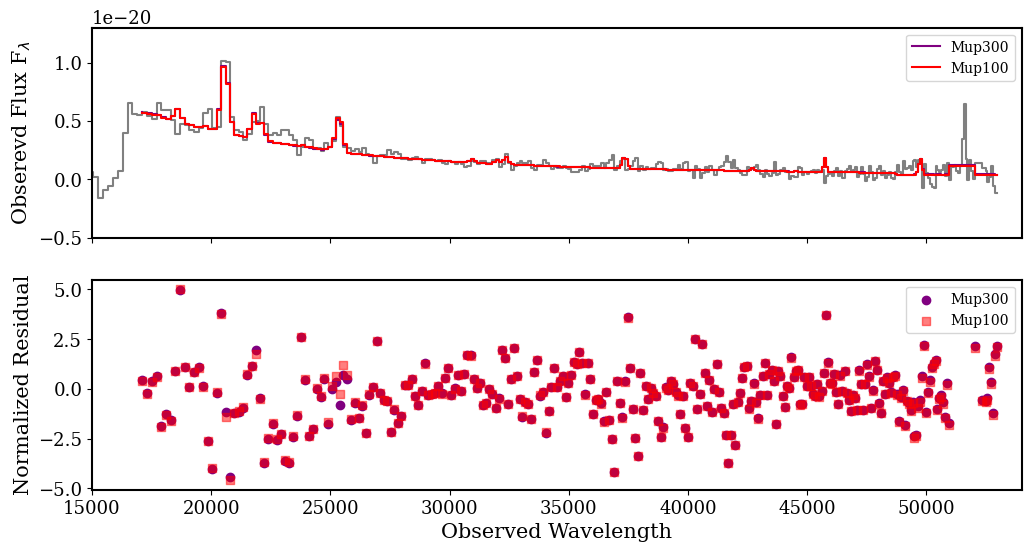

In [393]:
fig, axes = plt.subplots(2, 1, figsize = (12, 6), sharex = True)

ax = axes[0]
ax.step(wave, flux, color = 'gray')
ax.step(marg_wave_300, np.median(marg_mup300_default, axis = 0), color = 'purple', label = 'Mup300')
ax.step(marg_wave, np.median(marg_sed, axis = 0), color = 'red', label = 'Mup100')
ax.set_ylabel(r'Obserevd Flux F$_{\lambda}$', fontsize = 15)
ax.legend()
ax.set_xlim(15000, 54000)
ax.set_ylim(-0.5e-20, 1.3e-20)

ax1 = axes[1]

ax1.scatter(marg_wave_300, residuals_300, marker = 'o', color = 'purple', label = 'Mup300')
ax1.scatter(marg_wave, residuals, marker = 's', color = 'red', alpha = 0.5, label = 'Mup100')
ax1.set_ylabel('Normalized Residual', fontsize = 15)
ax1.set_xlabel('Observed Wavelength', fontsize = 15)
ax1.legend()
plt.show()

Grabbing SEDs
Convolving Full SED to Prism Resolution
Convolving AGN SED to Prism Resolution


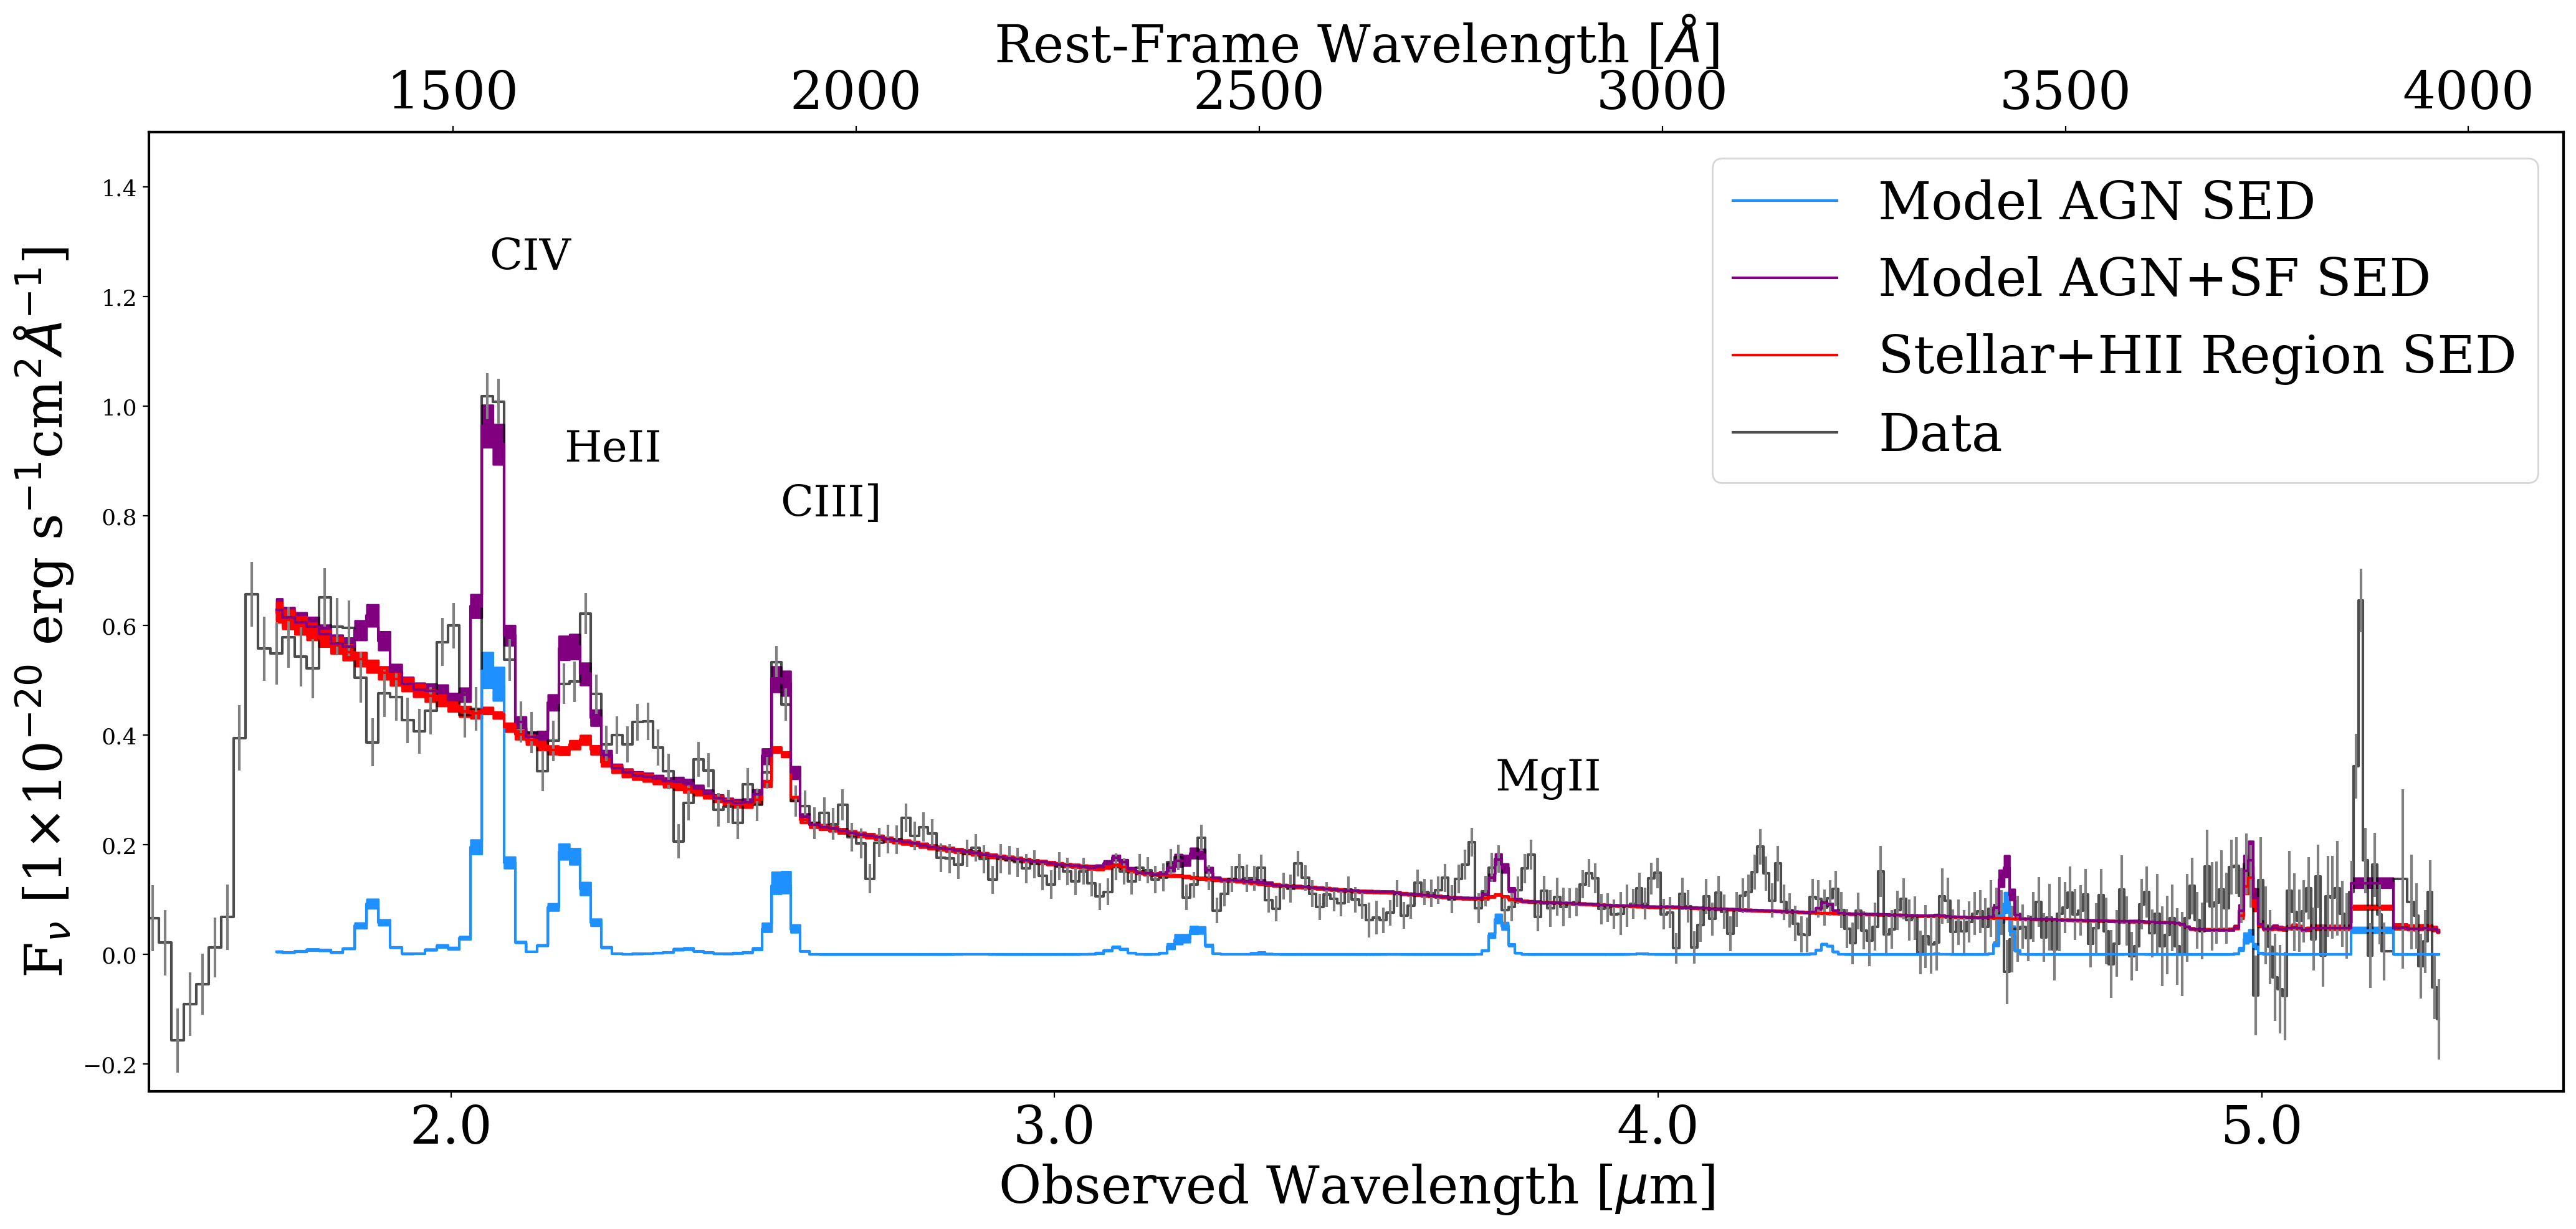

In [6]:
fig, axes = main_plot_components(hdu_agn_mup100_logU, wave, flux, fluxerr)

In [82]:
# df_mup100_default

In [7]:
def grab_bic(hdu, wave, flux, fluxerr, kind = 'median'):

    marg_wave, marg_seds = grab_marginal(hdu)
    df = get_posterior_df(hdu)

    if kind == 'median':
        bic = compute_bic_region(df, marg_wave[0], np.median(marg_seds, axis = 0), wave, flux, fluxerr)
    elif kind == 'best':
        best_idx = np.argmax(df.ln_likelihood.values)
        bic = compute_bic_region(df, marg_wave[0], marg_seds[best_idx], wave, flux, fluxerr)
    else:

        bic = np.array([compute_bic_region(df, marg_wave[0], x, wave, flux, fluxerr) for x in marg_seds])
    
    
    return bic

In [8]:
def plot_marginal(hdu, wave, flux, fluxerr, model):

    marg_wave, marg_seds = grab_marginal(hdu)

    l16, med, u84 = np.percentile(marg_seds, q = (16, 50, 84), axis = 0)
    bic = grab_bic(hdu, wave, flux, fluxerr, kind = 'median')
    
    
    plt.figure(figsize = (12, 6))
    plt.title(f'AGN+SF: {model}')
    plt.step( wave, flux, where = 'mid', color = 'gray')
    plt.step(marg_wave[0], med, color = 'blue', alpha = 0.5, label =f'BIC: {bic:.2f}')
    plt.fill_between(marg_wave[0], u84, l16, color = 'blue', alpha = 0.5, step = 'mid')
    plt.xlabel('Observed Wavelengths', fontsize = 15)
    plt.ylabel('Flux', fontsize = 15)
    plt.ylim(-1e-20, 1.3e-20)
    plt.legend()
    plt.show()

In [ ]:
df_mup100_logu_new

In [240]:
mup100_default_bic = grab_bic(hdu_agn_mup100_default, wave, flux, fluxerr, kind = None)
mup100_co_bic = grab_bic(hdu_agn_mup100_CO, wave, flux, fluxerr, kind = None)
mup100_logu_bic = grab_bic(hdu_agn_mup100_logU, wave, flux, fluxerr, kind = None)

mup300_default_bic = grab_bic(hdu_agn_mup300_default, wave, flux, fluxerr, kind = None)
mup300_co_bic = grab_bic(hdu_agn_mup300_CO, wave, flux, fluxerr, kind = None)
mup300_logu_bic = grab_bic(hdu_agn_mup300_logU, wave, flux, fluxerr, kind = None)

sfmup100_bic = grab_bic(hdu_sf_mup100, wave, flux, fluxerr, kind = None)
sfmup300_bic = grab_bic(hdu_sf_mup300, wave, flux, fluxerr, kind = None)

In [241]:
def format_median_pm_sigma(arr, precision=3, latex=True):
    """
    Compute median and 1-sigma bounds (16th and 84th percentiles) 
    and return as a formatted string.

    Parameters:
    -----------
    arr : array-like
        Input array of posterior samples.
    precision : int
        Number of decimal places to round to.
    latex : bool
        Whether to return LaTeX-formatted string (for tables/plots).

    Returns:
    --------
    str : formatted string
        Example: 0.25^{+0.05}_{-0.03}
    """
    arr = np.asarray(arr)
    p16, p50, p84 = np.percentile(arr, [16, 50, 84])
    plus = round(p84 - p50, precision)
    minus = round(p50 - p16, precision)
    median = round(p50, precision)

    if latex:
        return rf"${median}^{{+{plus}}}_{{-{minus}}}$"
    else:
        return f"{median} (+{plus}/-{minus})"

In [242]:
format_median_pm_sigma(mup100_default_bic)

'$233.833^{+11.004}_{-7.124}$'

In [243]:
format_median_pm_sigma(mup100_co_bic)

'$255.373^{+12.353}_{-8.904}$'

In [244]:
format_median_pm_sigma(mup100_logu_bic)

'$264.297^{+11.981}_{-9.042}$'

In [245]:
format_median_pm_sigma(mup300_default_bic)

'$235.173^{+10.872}_{-7.13}$'

In [246]:
format_median_pm_sigma(mup300_co_bic)

'$239.395^{+14.019}_{-9.876}$'

In [247]:
format_median_pm_sigma(mup300_logu_bic)

'$266.554^{+14.383}_{-9.422}$'

In [248]:
format_median_pm_sigma(sfmup100_bic)

'$519.577^{+8.944}_{-4.071}$'

In [249]:
format_median_pm_sigma(sfmup300_bic)

'$521.28^{+12.252}_{-6.238}$'

In [15]:
miri_spectra = pd.read_csv('data/spectra/MIRI_SPECTRA_for_MCMC.txt', sep = ' ', index_col = 0)


In [18]:
miri_spectra = pd.read_csv('data/spectra/MIRI_SPECTRA_for_MCMC.txt', sep = ' ', index_col = 0)
miri_wave = miri_spectra.wave_AA.values
print('Convolving Full and AGN SED to prism resolution')
agn_fraction, conv_agn, conv_full = compute_agn_fraction_percentiles_prism(hdu_agn_mup100_logU, wave)
print('Convolving Full and AGN SED to miri resolution')
miri_agn_fraction, miri_conv_agn, miri_conv_full = compute_agn_fraction_percentiles_miri(hdu_agn_mup100_logU, miri_wave)

Convolving Full and AGN SED to prism resolution


/Users/oac466/Desktop/BEAGLE-general/Analyze_Beagle_Output.py:828: RuntimeWarning: invalid value encountered in divide
  agn_fraction = conv_agn/conv_full


Convolving Full and AGN SED to miri resolution


/Users/oac466/Desktop/BEAGLE-general/Analyze_Beagle_Output.py:828: RuntimeWarning: invalid value encountered in divide
  agn_fraction = conv_agn/conv_full


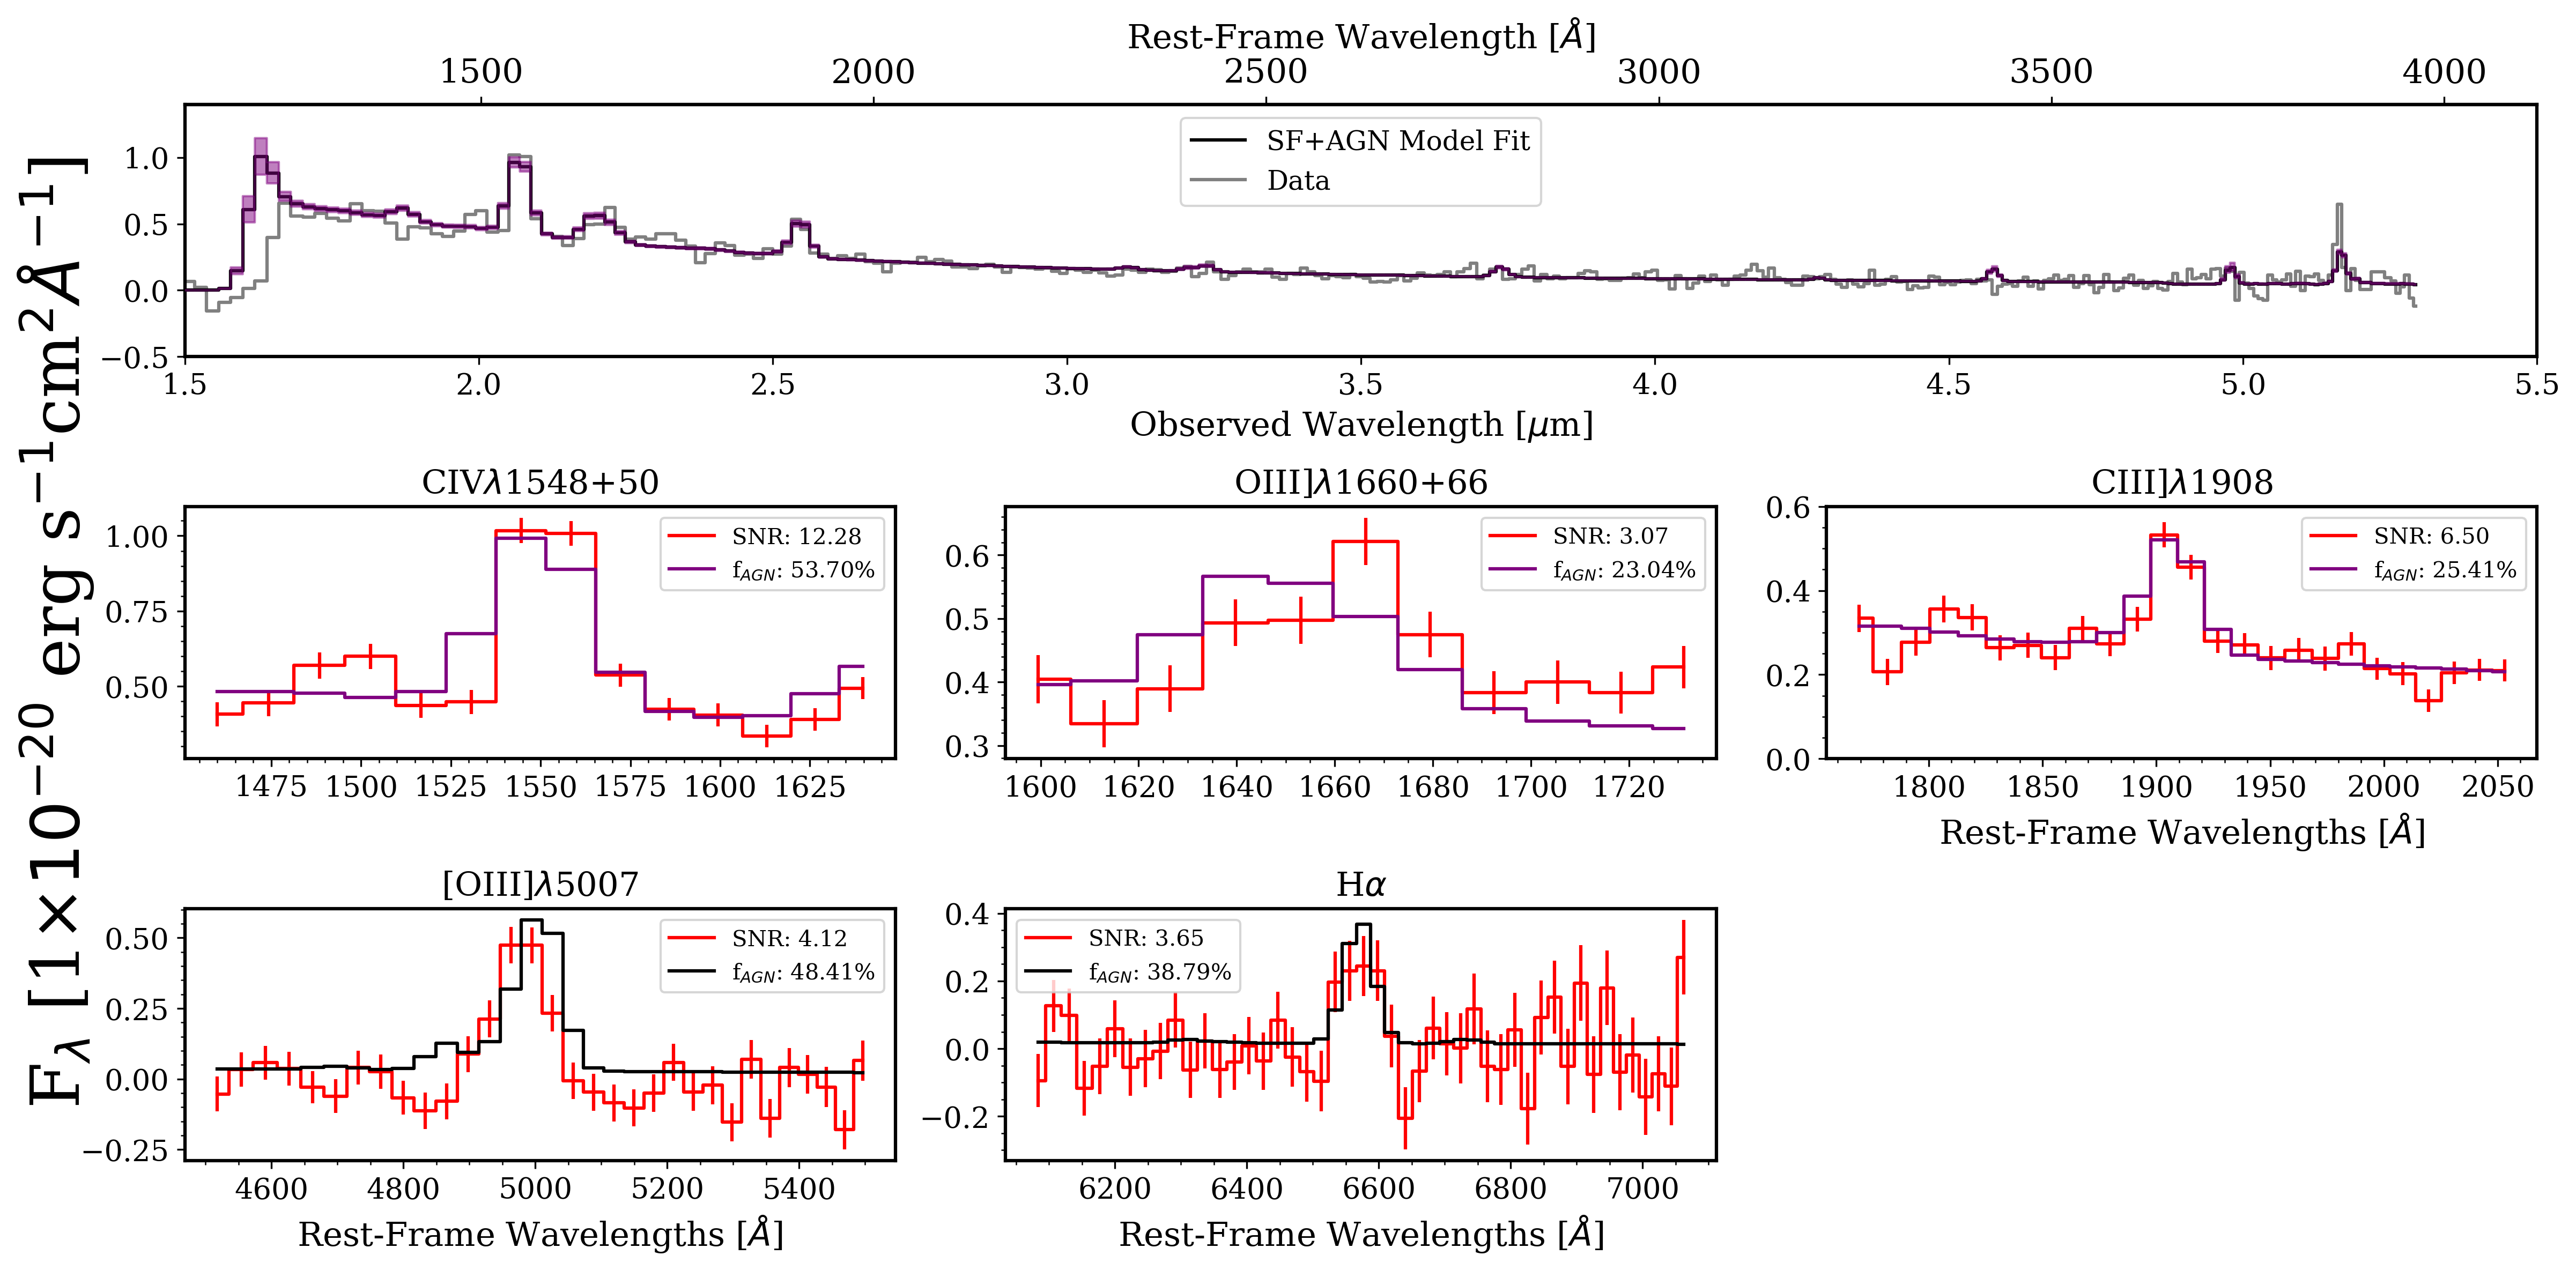

In [9]:
set_up_plot_panel(hdu_agn_mup100_logU, wave, flux, fluxerr)

In [20]:
#

In [10]:
LYA = 1215.67 #lya
CIV = 1549 #CIV
HEII = 1640 #HeII
NV = 1240
CIII = 1909
MGII = 2798

In [11]:
max_z = get_maxlnl_z(hdu_agn_mup100_logU)

In [12]:
zp1 = 1+max_z

In [16]:
def compute_agn_fraction(zmax, wave_prism, wave_miri, agn_fraction, miri_agn_fraction):

    zp1 = 1+zmax

    rest_wave_prism = wave_prism/zp1
    rest_wave_miri = wave_miri/zp1
    
    lines = [CIV, CIII, 1640.420, 1660.809, 2795.528	, 5007, 6563]
    lnames = ['CIV', 'CIII]', 'HeII', 'OIII]', 'MgII]', 'OIII5007', r'H$\alpha$']
    for line, name in zip(lines, lnames):

        if line < 5000:
            min_idx = np.argmin(np.abs(rest_wave_prism - line))
        
            l16, med, u84 = agn_fraction[0], agn_fraction[1], agn_fraction[2]
        
            print(f'AGN Fraction for {name} is: {med[min_idx]}, +{u84[min_idx]-med[min_idx]}, -{med[min_idx]-l16[min_idx]}')
        else:
            min_idx = np.argmin(np.abs(rest_wave_miri - line))
        
            l16, med, u84 = miri_agn_fraction[0], miri_agn_fraction[1], miri_agn_fraction[2]
        
            print(f'AGN Fraction for {name} is: {med[min_idx]}, +{u84[min_idx]-med[min_idx]}, -{med[min_idx]-l16[min_idx]}')
    

In [21]:
compute_agn_fraction(max_z, wave, miri_spectra.wave_AA.values, agn_fraction, miri_agn_fraction)

AGN Fraction for CIV is: 0.5362847881789994, +0.013580519529242219, -0.01052939538295905
AGN Fraction for CIII] is: 0.2561733801134916, +0.03715947974634726, -0.019029087173189574
AGN Fraction for HeII is: 0.3338719577165144, +0.013769350911891465, -0.011166636554157894
AGN Fraction for OIII] is: 0.23415344965279702, +0.013663727851642271, -0.013106719071242778
AGN Fraction for MgII] is: 0.3704784480030766, +0.031083675623657436, -0.022828534642259424
AGN Fraction for OIII5007 is: 0.48354160167266036, +0.040425112547007425, -0.016808232110524735
AGN Fraction for H$\alpha$ is: 0.3926209753189202, +0.022263651145406738, -0.013856972046901117


In [84]:
def get_galaxy_properties(hdu):

    df = Table(hdu['GALAXY PROPERTIES'].data).to_pandas()
    return df

In [87]:
df = get_galaxy_properties(hdu_agn_mup100_default)

In [99]:
def mbh_mstar_relation():

    m_star = np.linspace(7.5, 11, 1000)
    lines = np.zeros((1000, 1000))
    for i in range(1000):
        coeffs = np.random.normal(loc = [1.12, -2.54], scale = [0.08, 0.75])
    
        equation = coeffs[0] * m_star + (coeffs[1])
        lines[i] = equation
    return m_star, lines

def BH_Mass_estimates(agn_emission_table, eddington_ratio = 1):

    logLacc = np.array(agn_emission_table['agn_lacc']).astype(float)
    L_erg_s = (10**logLacc) * u.erg/u.s
    L_Lsun = L_erg_s.to(u.Lsun)

    Mass = L_Lsun/(3.2e4 * (u.Lsun/u.M_sun))/ eddington_ratio
    return Mass

In [564]:
df = get_posterior_df(hdu_agn_mup100_default)

In [243]:
bh_mass = BH_Mass_estimates(df).value

In [2]:
# plot_bhmass_vs_redshift(df)

In [3]:
# plot_mstellar_mbh(hdu_agn_mup100_default)

In [109]:
def compute_emission_flux(wave, flux, line, window, zp1, plot = None):

    rest_wave = wave/zp1
    rest_flux = flux
    
    checkwave, checkflux = grab_spectral_region(rest_wave, rest_flux, line, window)

    xarr = np.concatenate((checkwave[:2], checkwave[-2:]))
    yarr = np.concatenate((checkflux[:2], checkflux[-2:]))

    coeffs = np.polyfit(xarr, yarr, deg=1)
    fit_line = np.poly1d(coeffs)
    cont_flux = fit_line(checkwave)
    cont_sub = checkflux - cont_flux

    if plot:
        plt.figure(figsize = (10, 5))
        plt.step(checkwave, cont_sub)
        plt.show()
    
    return np.trapezoid(cont_sub, checkwave)
    

In [123]:
def models_fluxes(hdul):

    max_z = get_maxlnl_z(hdu)
    zp1 = 1+max_z
    
    line_list = [CIV, 1908.734, 5007, 6564]
    window_list = [60, 60, 60, 60]
    #actual_data = np.array([25.7e-19, 9.1e-19, 4.7e-18, 2.5e-18])
    #conv_list = [conv_full, conv_full, miri_conv_full, miri_conv_full]
    waves = [wave, wave, miri_spectra.wave_AA.values, miri_spectra.wave_AA.values]
    line_name = ['CIV', 'CIII]', 'OIII5007', 'Halpha']
    #error = [0.6e-19, 0.2e-19, 0.5e-18, 0.7e-18]
    
    fluxes = []
    lerr = []
    uerr = []
    
    for hdu in hdul:

        full_sed_wave, full_sed = read_full_sed(hdu)
    
        l16_full, med_full, u84_full = np.percentile(full_sed, q = (16, 50, 84), axis = 0)
        
        conv_model_l16 = convolve_model_spec(rwave*1e4, R, full_sed_wave*zp1, l16_full, wave, oversample = 75)
        conv_model_med = convolve_model_spec(rwave*1e4, R, full_sed_wave*zp1, med_full, wave, oversample = 75)
        conv_model_u84 = convolve_model_spec(rwave*1e4, R, full_sed_wave*zp1, u84_full, wave, oversample = 75)
        
        miri_conv_model_l16 = convolve_model_spec(wave_miri*1e4, r_miri, full_sed_wave*zp1, l16_full, miri_wave, oversample = 75)
        miri_conv_model_med = convolve_model_spec(wave_miri*1e4, r_miri, full_sed_wave*zp1, med_full, miri_wave, oversample = 75)
        miri_conv_model_u84 = convolve_model_spec(wave_miri*1e4, r_miri, full_sed_wave*zp1, u84_full, miri_wave, oversample = 75)
        
        conv_list_l16 = [conv_model_l16, conv_model_l16, miri_conv_model_l16, miri_conv_model_l16]
        conv_list_med = [conv_model_med, conv_model_med, miri_conv_model_med, miri_conv_model_med]
        conv_list_u84 = [conv_model_u84, conv_model_u84, miri_conv_model_u84, miri_conv_model_u84]
        
        model_fluxes_l16 = [compute_emission_flux(wav, conv, L, w, zp1) for wav, conv, L, w in zip(waves, conv_list_l16, line_list, window_list)]
        model_fluxes_med = [compute_emission_flux(wav, conv, L, w, zp1, plot = True) for wav, conv, L, w in zip(waves, conv_list_med, line_list, window_list)]
        model_fluxes_u84 = [compute_emission_flux(wav, conv, L, w, zp1) for wav, conv, L, w in zip(waves, conv_list_u84, line_list, window_list)]
        
        model_uerr = np.array(model_fluxes_u84) - np.array(model_fluxes_med)
        model_lerr = np.array(model_fluxes_med) - np.array(model_fluxes_l16)

        fluxes.append(model_fluxes_med)
        lerr.append(model_lerr)
        uerr.append(model_uerr)

    #df = pd.DataFrame({'Fluxes': fluxes, 
     #                  'lerr': lerr, 
    #                   'uerr': uerr})

    #return df

In [111]:
hdulist = [hdu_agn_mup100_default, hdu_agn_mup100_CO, hdu_agn_mup300_default, hdu_agn_mup300_CO, hdu_sf_mup100, hdu_sf_mup300]

In [591]:
test_df = models_fluxes(hdulist)

In [151]:
def plot_fluxes(hdu, wave, miri_wave):
    
    max_z = get_maxlnl_z(hdu)
    zp1 = 1+max_z
    
    line_list = [CIV, 1908.734, 4980, 6564]
    window_list = [60, 60, 150, 60]
    actual_data = np.array([25.7e-19, 9.1e-19, 4.7e-18, 2.5e-18])
    #conv_list = [conv_full, conv_full, miri_conv_full, miri_conv_full]
    waves = [wave, wave, miri_spectra.wave_AA.values, miri_spectra.wave_AA.values]
    line_name = ['CIV', 'CIII]', 'OIII5007', 'Halpha']
    error = [0.6e-19, 0.2e-19, 0.5e-18, 0.7e-18]

    full_sed_wave, full_sed = read_full_sed(hdu)
    
    l16_full, med_full, u84_full = np.percentile(full_sed, q = (16, 50, 84), axis = 0)
    
    conv_model_l16 = convolve_model_spec(rwave*1e4, R, full_sed_wave*zp1, l16_full, wave, oversample = 75)
    conv_model_med = convolve_model_spec(rwave*1e4, R, full_sed_wave*zp1, med_full, wave, oversample = 75)
    conv_model_u84 = convolve_model_spec(rwave*1e4, R, full_sed_wave*zp1, u84_full, wave, oversample = 75)
    
    miri_conv_model_l16 = convolve_model_spec(wave_miri*1e4, r_miri, full_sed_wave*zp1, l16_full, miri_wave, oversample = 75)
    miri_conv_model_med = convolve_model_spec(wave_miri*1e4, r_miri, full_sed_wave*zp1, med_full, miri_wave, oversample = 75)
    miri_conv_model_u84 = convolve_model_spec(wave_miri*1e4, r_miri, full_sed_wave*zp1, u84_full, miri_wave, oversample = 75)
    
    conv_list_l16 = [conv_model_l16, conv_model_l16, miri_conv_model_l16, miri_conv_model_l16]
    conv_list_med = [conv_model_med, conv_model_med, miri_conv_model_med, miri_conv_model_med]
    conv_list_u84 = [conv_model_u84, conv_model_u84, miri_conv_model_u84, miri_conv_model_u84]
    
    model_fluxes_l16 = [compute_emission_flux(wav, conv, L, w, zp1) for wav, conv, L, w in zip(waves, conv_list_l16, line_list, window_list)]
    model_fluxes_med = [compute_emission_flux(wav, conv, L, w, zp1, plot = None) for wav, conv, L, w in zip(waves, conv_list_med, line_list, window_list)]
    model_fluxes_u84 = [compute_emission_flux(wav, conv, L, w, zp1) for wav, conv, L, w in zip(waves, conv_list_u84, line_list, window_list)]
    
    model_uerr = np.array(model_fluxes_u84) - np.array(model_fluxes_med)
    model_lerr = np.array(model_fluxes_med) - np.array(model_fluxes_l16)
    
    plt.figure(figsize = (10, 5))
    plt.ylabel('Integrated Line Flux', fontsize = 15)
    plt.errorbar(line_name, actual_data, yerr = error, label = 'Data', fmt = 'o', color = 'black', capsize=2)
    plt.errorbar(line_name, model_fluxes_med, yerr = [model_lerr, model_uerr], label = 'Model', fmt = 'o', color = 'red', capsize=2)
    plt.legend()
    plt.show()

    #return miri_conv_model_med

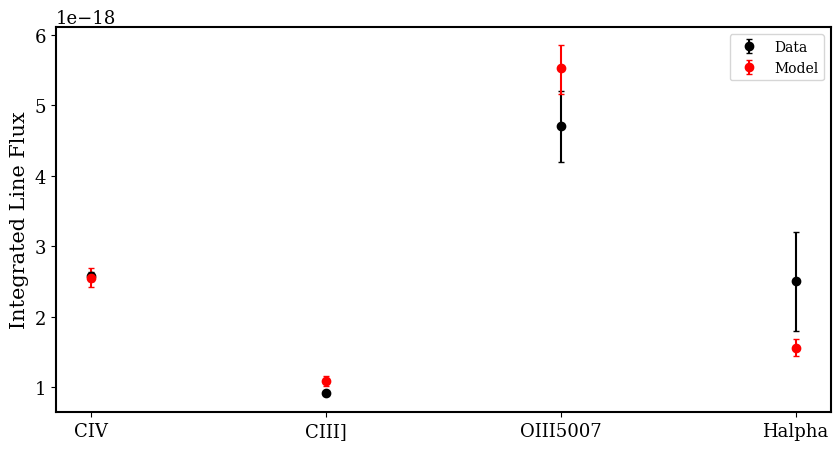

In [152]:
med_model_miri = plot_fluxes(hdu_agn_mup300_default, wave, miri_spectra.wave_AA.values)

(80000.0, 95000.0)

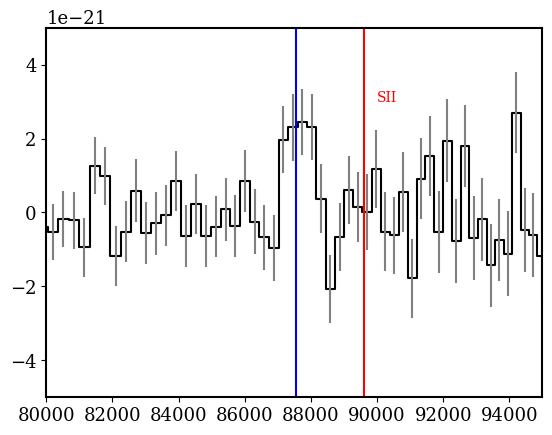

In [169]:
plt.step(miri_spectra.wave_AA.values, miri_spectra.flux_flam.values, where = 'mid', color = 'black')
plt.errorbar(miri_spectra.wave_AA.values, miri_spectra.flux_flam.values, yerr = miri_spectra.fluxerr_flam.values, 
            fmt = 'none', color = 'gray')
plt.ylim(-0.5e-20, 0.5e-20)
plt.axvline(6716*13.34, color = 'red')
plt.axvline(6564*13.34, color = 'blue')

plt.annotate('SII', (90000, 3e-21), xycoords = 'data', color = 'red')

plt.xlim(80000, 95000)

In [116]:
df = pd.read_csv('/Users/oac466/Downloads/MIRI_LRS_Resolution_Kendrew2015.txt', skiprows = 2, names = ['wave', 'R'])
wave_miri = df.wave.values
r_miri = df.R.values

In [117]:
wave_miri = df.wave.values
r_miri = df.R.values

In [4]:
# plot_BH_growth(hdu_agn_mup100_default)

In [5]:
# agn_emission_df = get_posterior_df(hdu_agn_mup300_default)

# bh_mass_edd1  = np.median(BH_Mass_estimates(agn_emission_df, eddington_ratio =   1).value)
# bh_mass_edd05 = np.median(BH_Mass_estimates(agn_emission_df, eddington_ratio = 0.5).value)
# bh_mass_edd01 = np.median(BH_Mass_estimates(agn_emission_df, eddington_ratio = 0.1).value)